# Geografisk analys av restauranger i Helsingborg

## Syfte

Syftet med projektet är att undersöka hur restauranger är geografiskt fördelade i Helsingborg och om det finns områden där restaurangerna är mer koncentrerade än andra. Projektet ska även demonstrera hur geografisk data kan samlas in, bearbetas, analyseras och visualiseras med Python.

## Området och dess relevans

Projektet är avgränsat till restauranger i Helsingborg. Restaurangdata hämtas från Helsingborgs stads restaurangregister och innehåller bland annat restaurangernas namn och adresser. Adresserna används sedan för att hitta restaurangernas geografiska positioner.

Geografisk data är relevant inom Data Science eftersom den kan användas för att identifiera mönster och koncentrationer som inte alltid är tydliga i vanlig tabulär data. Genom att kombinera databehandling, spatial analys och visualisering kan data användas för att undersöka hur olika verksamheter är geografiskt fördelade. Detta är relevant för exempelvis analyser av kundbeteenden, marknader, samhällsplanering och lokalisering av verksamheter.

## Viktiga begrepp

### Geodata
Geodata är information som är kopplad till en geografisk position. I projektet representeras restaurangernas positioner med koordinater i form av latitude och longitude.

### Geokodning
Geokodning innebär att en adress omvandlas till geografiska koordinater. I projektet används Nominatim för att omvandla restaurangernas adresser till latitude och longitude.

### GeoDataFrame
En GeoDataFrame är en datastruktur i GeoPandas som kombinerar vanlig tabulär data med geografisk information. I projektet används den för att representera restaurangerna som geografiska punkter.

### Spatial analys
Spatial analys innebär att analysera data utifrån dess geografiska position. I projektet används ett rutnät med 500 × 500 meters rutor för att undersöka hur många restauranger som finns inom olika områden.

### Spatial join
En spatial join används för att koppla geografiska objekt till varandra baserat på deras position. I projektet används den för att avgöra vilken ruta varje restaurang ligger inom och därefter räkna antalet restauranger per ruta.

## Genomförande

Projektet genomfördes som ett dataflöde där restaurangdata först hämtades, därefter bearbetades och slutligen analyserades och visualiserades. Lösningen delades upp i flera Python-moduler där varje modul ansvarar för ett specifikt steg i processen. Detta gjorde koden mer strukturerad och gjorde det möjligt att styra hela arbetsflödet från main.py.

### Datainsamling

Projektet börjar med att restaurangdata hämtas från Helsingborgs stads restaurangregister med hjälp av pandas.read_html(). Den relevanta informationen sparas som en CSV-fil för att kunna användas i nästa steg.

### Geokodning

Eftersom registret innehåller adresser men inte geografiska koordinater används biblioteket Geopy tillsammans med tjänsten Nominatim för att omvandla adresserna till latitude och longitude. För att undvika onödiga API-anrop kontrollerar programmet om en geokodad fil redan finns och geokodar endast restauranger som saknar koordinater.

### Datavalidering

Efter geokodningen kontrolleras datan innan den används vidare. Valideringen säkerställer att de obligatoriska kolumnerna finns, att namn och adresser inte saknas och att koordinaterna innehåller giltiga numeriska värden. Funktionen testades även med Pytest genom flera automatiserade tester för att verifiera att valideringen fungerar som förväntat.

### Skapande av geografisk data

Med hjälp av GeoPandas omvandlas den geokodade datan till en GeoDataFrame där varje restaurang representeras som en geografisk punkt. Datan sparas även som en GeoJSON-fil för att kunna användas i den fortsatta analysen.

### Spatial analys

För att undersöka restaurangernas geografiska fördelning omvandlas koordinaterna först till koordinatsystemet EPSG:3006, där avstånd mäts i meter. Därefter skapas ett rutnät med rutor på 500 × 500 meter över Helsingborg. Med hjälp av en spatial join räknas hur många restauranger som finns inom varje ruta, vilket gör det möjligt att identifiera områden med hög respektive låg restaurangtäthet.

## Visualisering

Slutligen skapas två interaktiva kartor med Folium. Den första visar restaurangernas positioner tillsammans med namn och adress, medan den andra visar restaurangtätheten i rutnätet med hjälp av en färgskala där mörkare färger representerar högre koncentration av restauranger.


## Resultat

Projektet innehåller totalt 224 restauranger med geografiska koordinater. För att undersöka hur restaurangerna är fördelade geografiskt delades det analyserade området in i 1 148 rutor, där varje ruta är 500 × 500 meter.

Täthetsanalysen visar att restaurangerna inte är jämnt fördelade över området. Medianen är 0 restauranger per ruta, vilket innebär att minst hälften av rutorna inte innehåller någon restaurang. Även 75:e percentilen är 0, vilket visar att restaurangerna är koncentrerade till ett relativt litet antal rutor. Den mest restaurangtäta rutan innehåller 42 restauranger. Om en restaurangpunkt ligger inom en viss 500 × 500 meters ruta kopplas restaurangen till den rutan. Om fem restauranger ligger i samma ruta får rutan värdet 5.

Medelvärdet är cirka 0,19 restauranger per ruta, men eftersom många rutor saknar restauranger och ett fåtal rutor innehåller många restauranger blir medelvärdet mindre representativt för de mest koncentrerade områdena.

In [1]:
import pandas as pd
import geopandas as gdp
import folium

In [ ]:
gdf = gdp.read_file("../data/processed/restaurants.geojson")
grid = gdp.read_file("../data/processed/restaurant_density.geojson")

print(f"Antal Restauranger i Helsingborg:", len(gdf))
print(f"Antal rutor: {len(grid)}")
print(f"Täthetsanalys: {grid['restaurant_count'].describe()}")

print(grid.sort_values("restaurant_count", ascending=False)[
    ["restaurant_count", "geometry"]
].head(10))

gdf.head()

Antal Restauranger i Helsingborg: 224
Antal rutor: 1148
Täthetsanalys: count    1148.000000
mean        0.193380
std         1.955269
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        42.000000
Name: restaurant_count, dtype: float64
     restaurant_count                                           geometry
144                42  POLYGON ((356370.547 6213645.881, 356370.547 6...
184                41  POLYGON ((356870.547 6213145.881, 356870.547 6...
143                18  POLYGON ((356370.547 6213145.881, 356370.547 6...
183                15  POLYGON ((356870.547 6212645.881, 356870.547 6...
185                15  POLYGON ((356870.547 6213645.881, 356870.547 6...
145                 5  POLYGON ((356370.547 6214145.881, 356370.547 6...
379                 5  POLYGON ((359370.547 6208145.881, 359370.547 6...
522                 5  POLYGON ((360870.547 6218145.881, 360870.547 6...
103                 4  POLYGON ((355870.547 6213645.881, 355870.5

,name,address,Serveringstider,latitude,longitude,geometry
0,Amore Fantasia,Norra Storgatan 1,11:30:00,56.047380,12.695464,POINT (12.69546 56.04738)
1,Aroma Restaurang,Norra Kyrkogatan 10,11:00:00,56.046346,12.695143,POINT (12.69514 56.04635)
2,Backhaus Oceanhamnen,Henckels Torg 4,11:00:00,56.041952,12.691972,POINT (12.69197 56.04195)
3,Badvakten,Drottninggatan 95,11:00:00,56.058353,12.682179,POINT (12.68218 56.05835)
4,Banh Mi King (city),Bruksgatan 34,11:00:00,56.043902,12.697081,POINT (12.69708 56.0439)


### Geografisk fördelning

Kartan visar den geografiska fördelningen av restaurangerna i Helsingborg. Varje punkt representerar en restaurang och genom att klicka på en punkt kan restaurangens namn och adress visas.

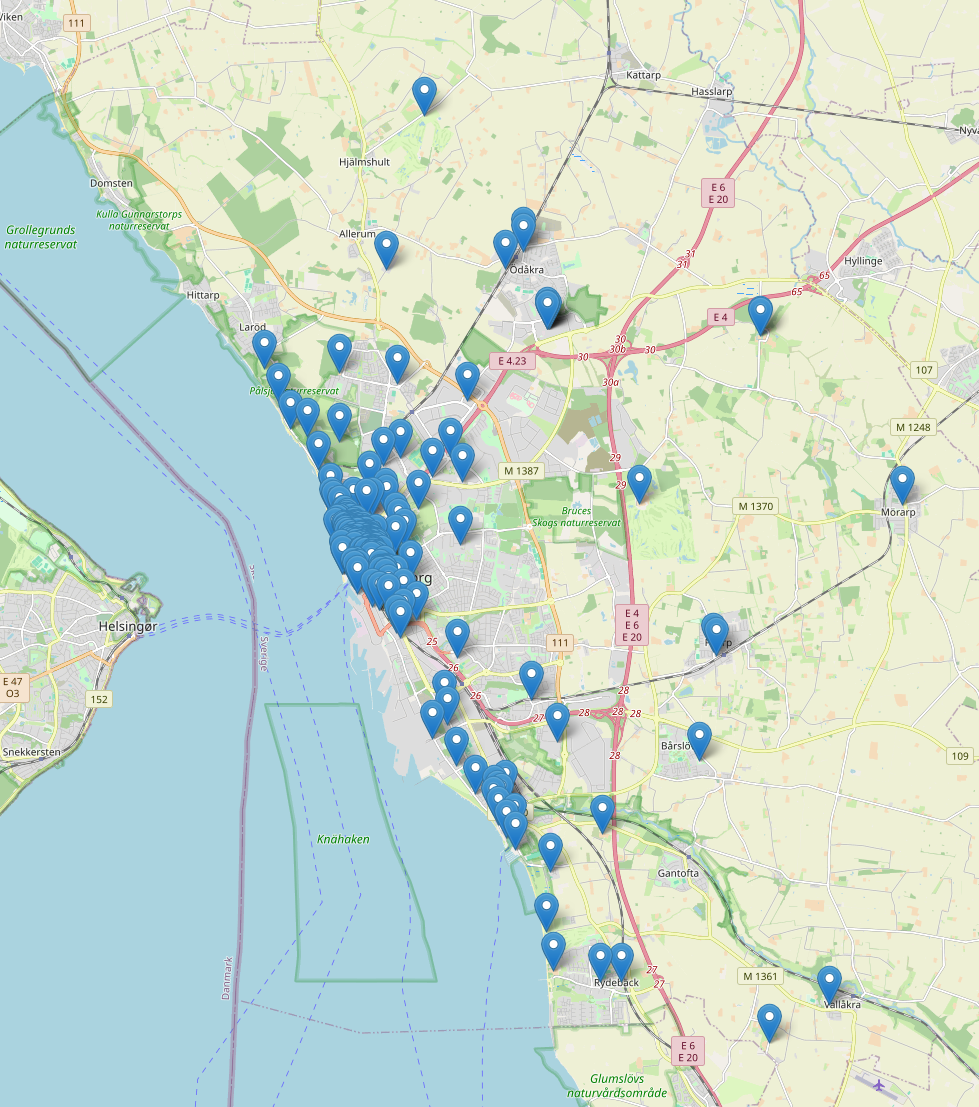

In [27]:
from IPython.display import Image, display

display(Image(
    filename="../data/processed/restaurants_map.png",
    width=800
))

### Restaurangtäthet

Täthetskartan visar tydligare var restaurangerna är koncentrerade. De mörkare rutorna innehåller fler restauranger medan ljusare rutor innehåller färre eller inga restauranger.

Resultatet visar att restaurangutbudet är koncentrerat till vissa geografiska områden. Detta stöds även av den statistiska analysen, där 75 procent av rutorna innehåller noll restauranger medan den mest koncentrerade rutan innehåller 42 restauranger.

Resultatet besvarar därmed projektets frågeställning: det finns tydliga geografiska mönster och koncentrationer i restaurangutbudet i Helsingborg.

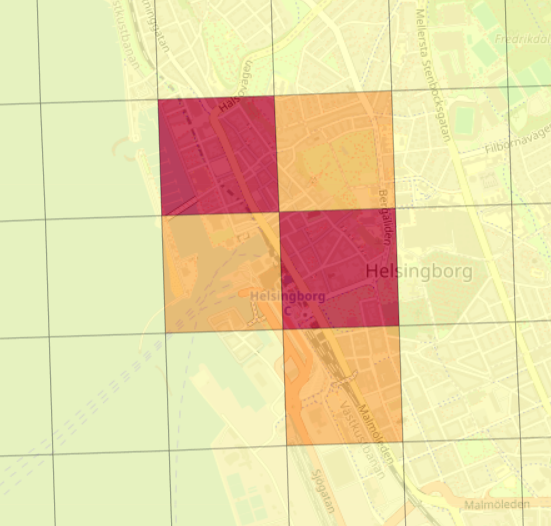

In [26]:
display(Image(
    filename="../data/processed/restaurant_density_map.png",
    width=800
))

## Begränsningar och möjliga förbättringar

### Begränsningar

- Den interaktiva Folium-kartan kunde inte visas direkt i notebooken i VS Code eftersom notebooken krävde att vara betrodd. Därför användes en bild av kartan i rapporten.
- Restaurangerna är koncentrerade till vissa delar av det analyserade området. Eftersom analysen använder ett rutnät över hela det geografiska området innehåller många rutor inga restauranger.
- Ett rutnät passar bra när man vill jämföra geografiska koncentrationer mellan olika områden. Resultatet påverkas däremot av rutornas storlek. Mindre rutor kan ge en mer detaljerad bild av restaurangernas fördelning, medan större rutor ger en mer övergripande bild
- Geokodningen var inte helt automatisk. Vissa adresser kunde inte geokodas med Nominatim och behövde därför kompletteras manuellt. De manuella koordinaterna kan därför vara något mindre exakta.
- Analysen utgår från restaurangernas geografiska position och tar inte hänsyn till exempelvis restaurangernas storlek, antal kunder eller omsättning.

### Möjliga förbättringar

- En framtida förbättring skulle vara att använda **Leafmap** eller en annan lösning för att skapa och visa interaktiva kartor direkt i notebooken.
- Analysen skulle kunna utvecklas genom att jämföra restaurangtätheten med exempelvis befolkningstäthet eller olika områden i Helsingborg.
- Ett mindre eller mer anpassat rutnät skulle kunna användas för att få en mer detaljerad bild av restaurangtätheten.
- Geokodningen skulle kunna förbättras genom att använda en mer specialiserad geodatakälla eller kontrollera de manuellt angivna koordinaterna mer noggrant.
- Ett större dataset hade kunnat ge mer information, men samtidigt gjort analysen mer komplex och krävt mer databehandling.

## Koppling till yrkesrollen

I mitt projekt har jag använt mig av ett tydlig flöde som består av:
- Datainsamling från ett extern restaurangregister
- Datarengöring
- Datavalidering
- Analys
- Visualisering
- Tolkning av resultat

Python har använts genom hela projektet, bland annat tillsammans med Pandas, GeoPandas och Folium. Jag har även arbetat med geokodning, koordinatsystem och spatial analys. Projektet visar därför hur Python kan användas för att gå från rådata till ett analyserbart resultat och en tydlig visualisering.

En viktig del av yrkesrollen är även att kunna tolka resultat och presentera dem på ett begripligt sätt. I projektet har jag därför inte bara fokuserat på koden, utan även på att analysera vad resultaten faktiskt visar och vilka begränsningar analysen har.

I en verklig arbetsmiljö skulle samma typ av metod kunna användas för exempelvis geografisk marknadsanalys, lokalisering av verksamheter eller analys av kunders geografiska fördelning.

## Självreflektion
### Vad lärde du dig som du inte kunde innan?
Jag lärde mig framför allt att importera riktig data från en extern källa och omvandla adresser till datapunkter med hjälp av longitud och latitud. Jag lärde mig också att visualisera datapunkterna på en karta med hjälp av Folium samt att skapa spatiala rutor med hjälp av Shapely. Jag lärde mig också att använda ett tydlig flöde med moduler som har sina egna uppgifter istället för att ha allt i samma fil.

### Vad var svårast att förstå eller genomföra?
Det svåraste var att förstå hur den spatiala analysen fungerade och hur restaurangerna kopplades till de olika rutorna. Det var också en utmaning att geokoda alla adresser, eftersom vissa adresser inte kunde hittas automatiskt och behövde kompletteras manuellt.

### Vilket tekniskt val är du mest nöjd med och varför?
Jag är mest nöjd med valet av Nominatim, eftersom det gjorde det relativt enkelt att omvandla restaurangernas adresser till geografiska punkter med hjälp av koordinater. Det gjorde att jag kunde använda adresserna i den fortsatta geografiska analysen

### Vad hade du gjort annorlunda om du började om?
Om jag började om hade jag använt mig av Leafmap istället för Folium, eftersom rapportdelen hade blivit tydligare och enklare med en interaktiv karta direkt i rapporten istället för bilder.

### Vad skulle vara ett naturligt nästa steg om du fortsatte arbetet?
Om jag fortsatte arbetet skulle ett naturligt nästa steg vara att byta ut Folium mot Leafmap för att kunna skapa och visa interaktiva kartor direkt i rapporten. Det skulle göra resultatet tydligare och mer användarvänligt.

### Vilket betyg tycker du själv att arbetet motsvarar – G eller VG?
VG

### Motivera din bedömning genom att koppla till kraven för G och VG nedan.
Jag bedömer arbetet som VG eftersom det uppfyller mer än de grundläggande kraven för G. Jag har inte bara byggt en fungerande lösning, utan också förklarat och använt flera tekniska begrepp som geokodning, GeoDataFrame, koordinatsystem och spatial join. Jag har även gjort egna tekniska val, exempelvis att använda Nominatim för geokodning och ett rutnät på 500 × 500 meter för att analysera restaurangtäthet.

Jag har också reflekterat över styrkor och begränsningar i lösningen, exempelvis hur storleken på rutorna påverkar analysen och att vissa koordinater behövde kompletteras manuellt. Dessutom har jag använt datavalidering och tester med Pytest.

Det visar enligt mig en mer detaljerad förståelse för tekniken och inte bara att jag kan använda den, vilket motsvarar VG-kraven.

## Källor

- Helsingborgs stad. Restaurangregister.
  https://tillstandsenheten.helsingborg.se/alktwebbforms/Restaurants

- OpenStreetMap Foundation. Nominatim Usage Policy.
  https://operations.osmfoundation.org/policies/nominatim/

- Nominatim. Search API Documentation.
  https://nominatim.org/release-docs/latest/api/Search/

- GeoPandas Documentation.
  https://geopandas.org/en/stable/

- Shapely Documentation.
  https://shapely.readthedocs.io/

- Folium Documentation.
  https://python-visualization.github.io/folium/